### Project #4 - Geopandas: Mapping with Python
In this lab we'll learn how to use maps within Python, no ArcGIS needed.

In [1]:
## Import relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

from PIL import Image
from IPython.display import display

#### Creating a basic map in Geopandas
In order to map with Geopandas, we need what's called a "spatial variable".  A spatial variable can be latitude and longitude, a SHP file like from ArcGIS or a geoID that tells a system like Geopandas where specific data needs to go on built in maps.

In our NRI data set, we have either:
1. County Level Data
2. Census Tract Data

For the purposes of plotting, we can use either, but we'll use Census Tract data to plot for this lab.  Feel free to explore how to do mapping with County Level Data on your own.  Download the SHP file from the CDC website.  You also need all the other files in the download, so make sure all those files are in your working directory.

In [2]:
## Read the Census Tracts data
tracts = gpd.read_file("NRI_Shapefile_CensusTracts.shp")
##Verifications for Shape files
tracts.head()

,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,TRACT,TRACTFIPS,...,WNTW_ALRP,WNTW_ALRA,WNTW_ALR_N,WNTW_RISKV,WNTW_RISKS,WNTW_RISKR,NRI_VER,Shape_Leng,Shape_Area,geometry
0,T01001020100,Alabama,AL,01,Autauga,County,001,01001,020100,01001020100,...,7.410082e-09,0.000009,32.947366,214.404773,25.882367,Relatively Low,March 2023,19225.811017,1.388551e+07,"POLYGON ((-9626784.493 3827718.774, -9626802.4..."
1,T01001020200,Alabama,AL,01,Autauga,County,001,01001,020200,01001020200,...,7.410082e-09,0.000009,33.845738,335.526352,29.020596,Relatively Low,March 2023,11645.802680,4.687259e+06,"POLYGON ((-9625497.973 3827700.43, -9625504.76..."
2,T01001020300,Alabama,AL,01,Autauga,County,001,01001,020300,01001020300,...,7.410082e-09,0.000009,33.386570,494.226826,32.839033,Relatively Low,March 2023,12474.652420,7.550456e+06,"POLYGON ((-9623646.617 3823891.992, -9623666.3..."
3,T01001020400,Alabama,AL,01,Autauga,County,001,01001,020400,01001020400,...,7.410082e-09,0.000009,32.654955,517.167844,33.357513,Relatively Low,March 2023,14839.600848,9.007297e+06,"POLYGON ((-9622012.001 3826514.039, -9622007.2..."
4,T01001020501,Alabama,AL,01,Autauga,County,001,01001,020501,01001020501,...,7.410082e-09,0.000009,32.793527,558.901021,34.226799,Relatively Low,March 2023,13543.791893,8.736313e+06,"POLYGON ((-9619304.709 3823820.353, -9619304.3..."


In [4]:
###This checks for Coordinate Reference System (CRS)
#tracts.crs()
###Checks the geometries in the data
tracts.geometry.head()

0    POLYGON ((-9626784.493 3827718.774, -9626802.4...
1    POLYGON ((-9625497.973 3827700.43, -9625504.76...
2    POLYGON ((-9623646.617 3823891.992, -9623666.3...
3    POLYGON ((-9622012.001 3826514.039, -9622007.2...
4    POLYGON ((-9619304.709 3823820.353, -9619304.3...
Name: geometry, dtype: geometry

##### Clean data for mapping
When mapping, cleaning data is a bit different.  We need to check for the following items:
1. Does the data have the correct projection? - Data can be mapped to different types of maps and you always need to check that the latitude and the longitude are in the correct projection.
2. Does the data have NAs or odd features? - Latitude and longitude data does not always contain NAs, sometimes it has NaNs or weird numeric placeholders.  In our data we have -9999 as a placeholder.  We need to remove or convert these before we can map.

In [5]:
### Cleaning data - Dr. Lane's Example
# Check the projection and set it
tracts_clean = tracts.set_crs(epsg=4326,inplace=True, allow_override=True)
# 3. Now you can transform to a new CRS (e.g., Pseudo-Mercator)
tracts_clean = tracts_clean.to_crs(epsg=4326)
# Replace -9999 nulls with NaN
tracts_clean=tracts_clean.replace(-9999,np.nan)

In [ ]:
### Check data

In [6]:
# 1. Tell GeoPandas the data is actually Web Mercator (meters)
tracts_clean.crs="EPSG:3857"
# 2. Now properly convert it to degrees to match your xlim/ylim
tracts_clean = tracts_clean.to_crs(epsg=4326)
# Standard projection for US National maps
tracts_clean=tracts_clean.to_crs("ESRI:102003")

### First Map - NRI Risk in the United States
Using the SHP file, map the NRI value for the entire United States using the `RISK_SCORE` in the data set.

In [ ]:
print(tracts_clean)

In [7]:
# List of states/territories to exclude - we will plot the lower 48
exclude = ['Alaska', 'Hawaii', 'Puerto Rico', 'American Samoa', 
           'Guam', 'Northern Mariana Islands', 'Virgin Islands']
# Filter if your column is named 'STATE'
tracts_lower48 = tracts_clean[~tracts_clean['STATE'].isin(exclude)]

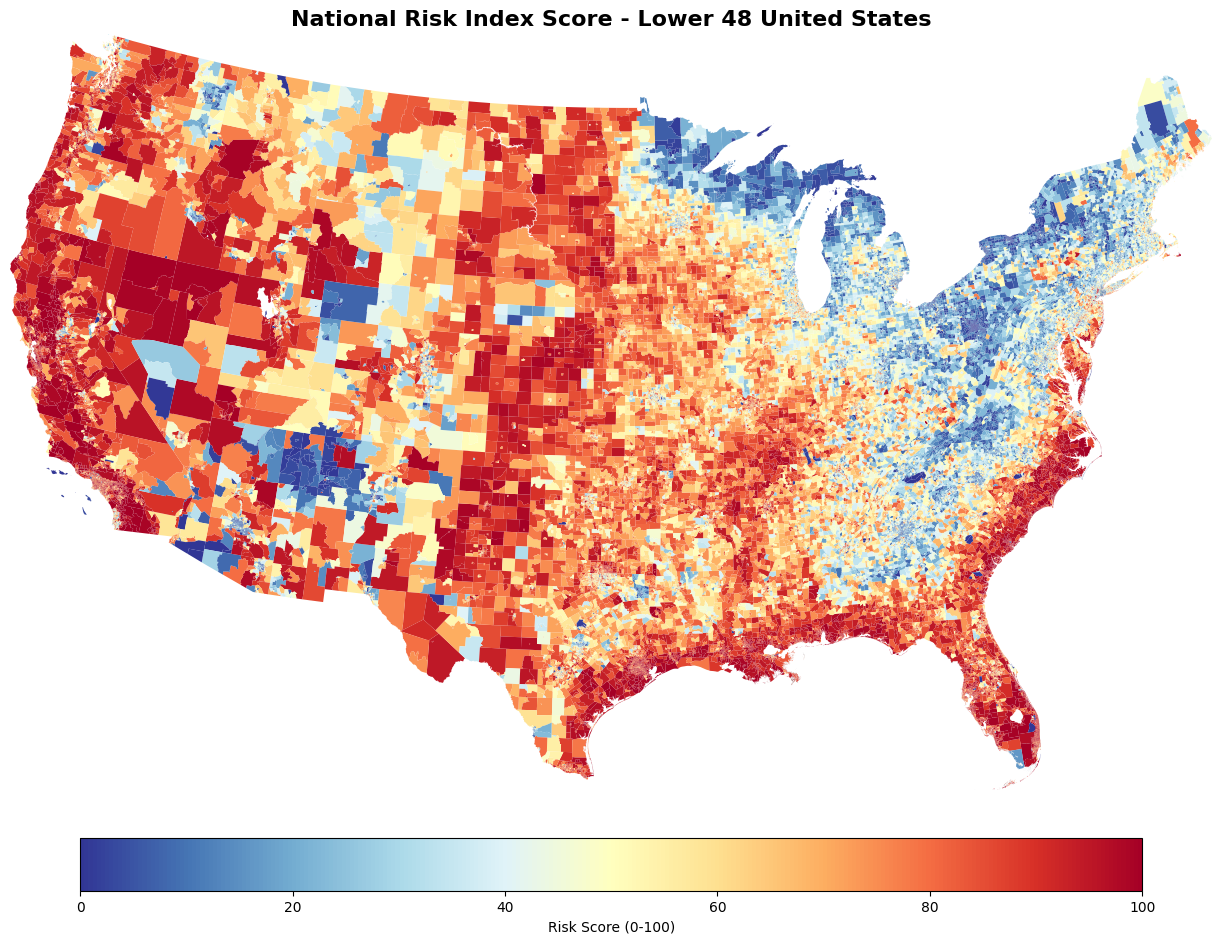

In [10]:
### Setup the plot
fix, ax = plt.subplots(1,1,figsize=(18,10))
tracts_lower48.plot(
    column="RISK_SCORE",
    cmap="RdYlBu_r",
    linewidth=0.0,
    ax=ax,
    legend=True,
    legend_kwds={"label": "Risk Score (0-100)", "orientation": "horizontal", "shrink": 0.6, "pad": 0.05},
    missing_kwds={"color": "lightgrey", "label": "No Data"},
)
##AUTO-ZOOM: Get bounds from the filtered data
minx, miny, maxx, maxy = tracts_lower48.total_bounds
# Apply the bounds with a tiny bit of "padding" (0.5 degrees) for a cleaner look
padding = 0.5
ax.set_xlim(minx - padding, maxx + padding)
ax.set_ylim(miny - padding, maxy + padding)
# 5. Final styling
ax.set_title("National Risk Index Score - Lower 48 United States", fontsize=16, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

### Second Map - focus on Singular States
Using the same SHP file, we can filter for specific States.  In my example, I will filter for Nebraska.

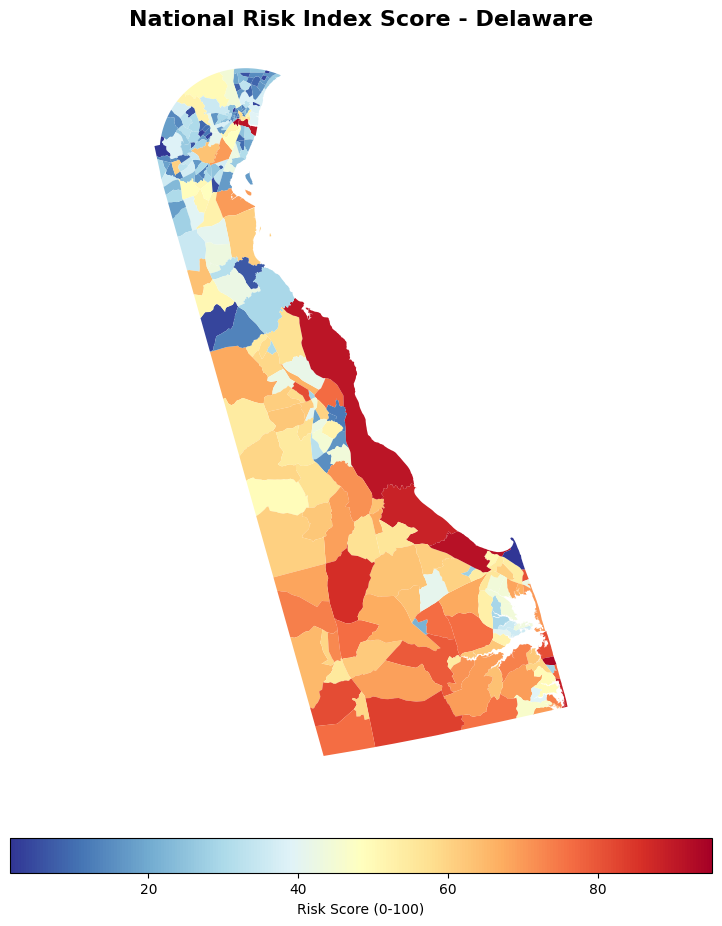

In [11]:
## State Map
state_name = "Delaware"  # <-- Change this to any state

state_map = tracts_clean[tracts_clean["STATE"].str.lower() == state_name.lower()]

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
state_map.plot(
    column="RISK_SCORE",
    cmap="RdYlBu_r",
    aspect = 1,
    linewidth=0.0,
    ax=ax,
    legend=True,
    legend_kwds={"label": "Risk Score (0-100)", "orientation": "horizontal", "shrink": 0.6, "pad": 0.05},
    missing_kwds={"color": "lightgrey", "label": "No Data"},
)
ax.set_title(f"National Risk Index Score - {state_name}", fontsize=16, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [14]:
##  Now test if you can use a different column.
tracts_clean.columns

Index(['NRI_ID', 'STATE', 'STATEABBRV', 'STATEFIPS', 'COUNTY', 'COUNTYTYPE',
       'COUNTYFIPS', 'STCOFIPS', 'TRACT', 'TRACTFIPS',
       ...
       'WNTW_ALRP', 'WNTW_ALRA', 'WNTW_ALR_N', 'WNTW_RISKV', 'WNTW_RISKS',
       'WNTW_RISKR', 'NRI_VER', 'Shape_Leng', 'Shape_Area', 'geometry'],
      dtype='object', length=469)

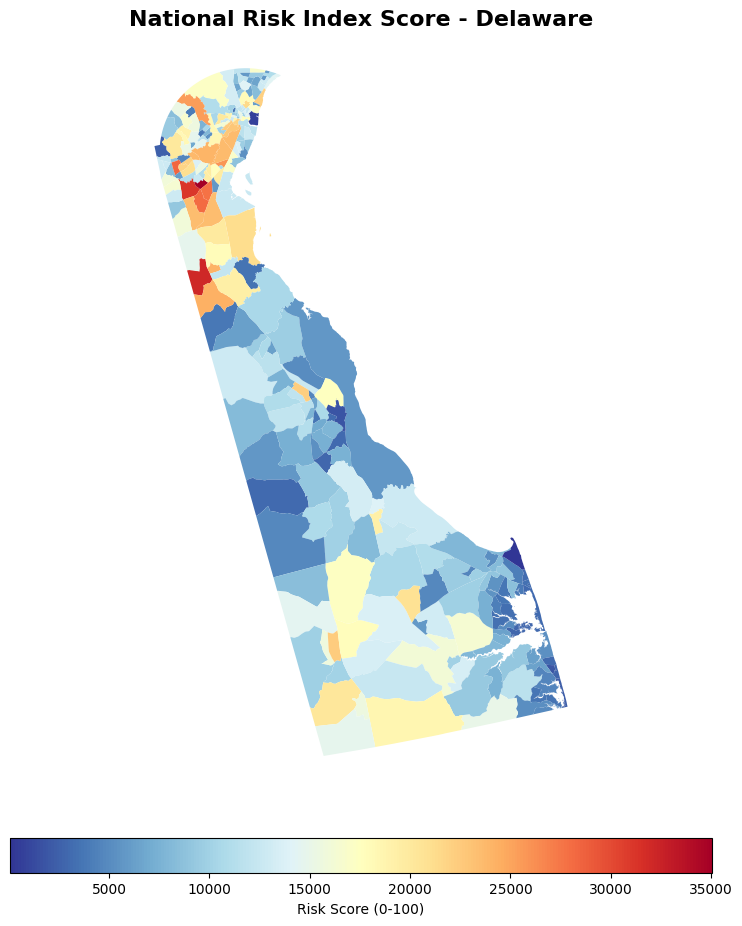

In [15]:
### Create the same plot with a different fill
state_name = "Delaware"  # <-- Change this to any state

state_map = tracts_clean[tracts_clean["STATE"].str.lower() == state_name.lower()]

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
state_map.plot(
    column="WNTW_RISKV",
    cmap="RdYlBu_r",
    aspect = 1,
    linewidth=0.0,
    ax=ax,
    legend=True,
    legend_kwds={"label": "Risk Score (0-100)", "orientation": "horizontal", "shrink": 0.6, "pad": 0.05},
    missing_kwds={"color": "lightgrey", "label": "No Data"},
)
ax.set_title(f"National Risk Index Score - {state_name}", fontsize=16, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

### Chloropleth Maps using NRI Risk Score
Now, we need to be able to make sure we have the correct number of categories and colors to create a chloropleth map.  When you examine your data set, your goal will be to plot your risk score in comparison to the NRI risk score.  This means you need to be able to tell Geopandas which columns of the data frame to plot.  Let's try this below.

C:\Users\owens\AppData\Local\Temp\ipykernel_48600\3646573584.py:21: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(title="Risk Rating", loc="lower left", fontsize=9)
C:\Users\owens\AppData\Local\Temp\ipykernel_48600\3646573584.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Risk Rating", loc="lower left", fontsize=9)


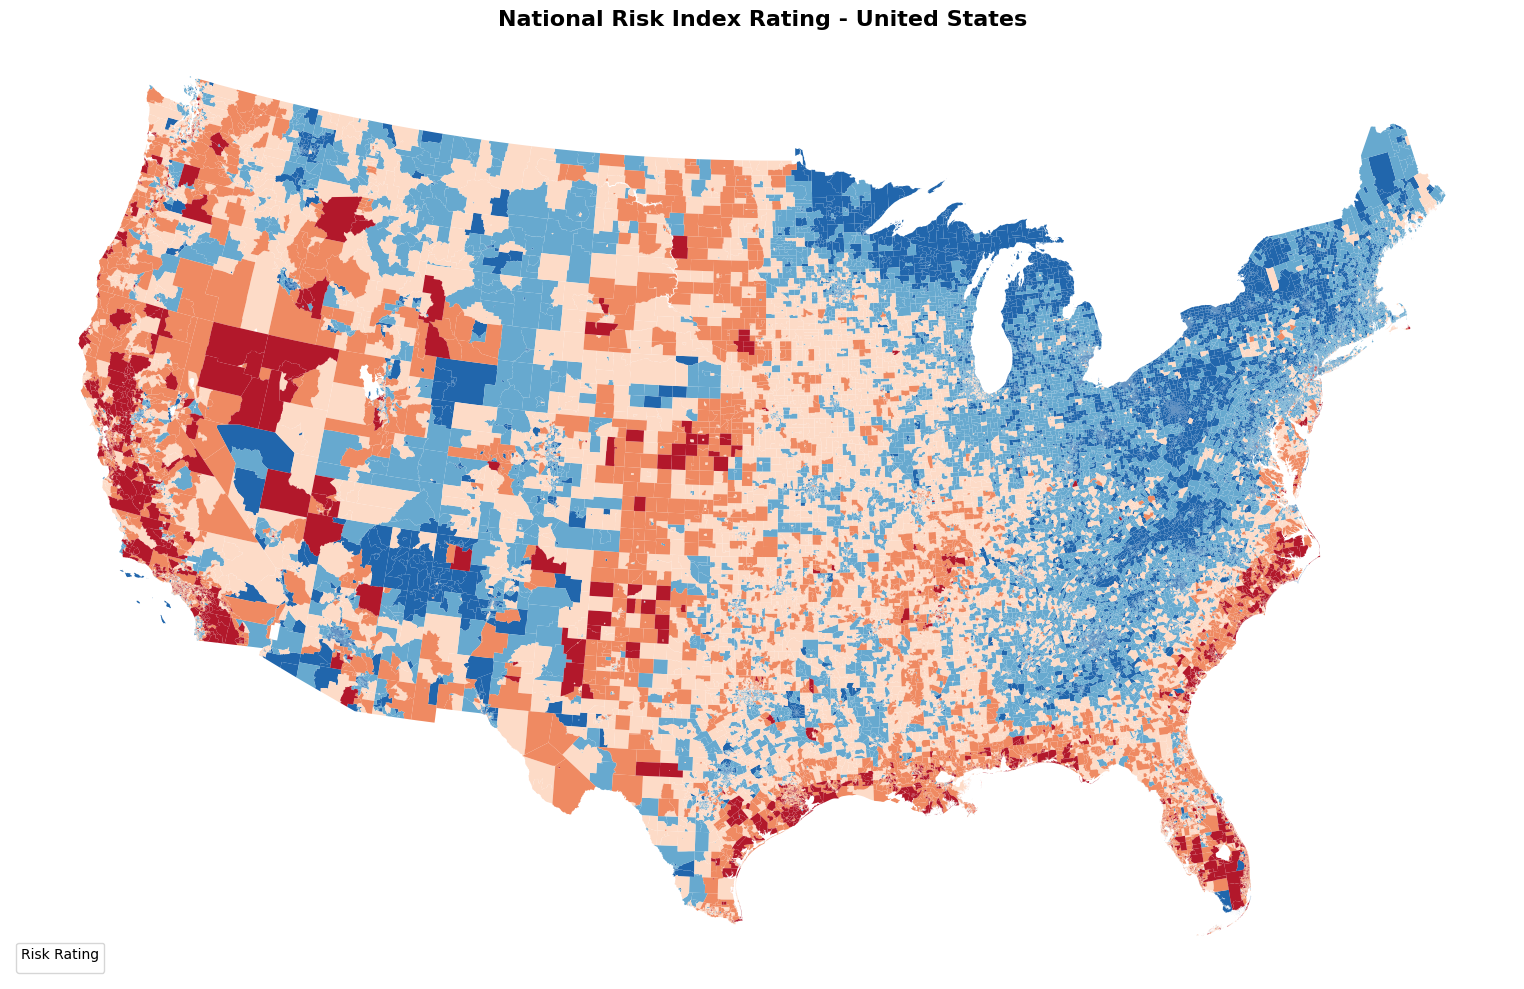

In [16]:
### Chloropleth Maps using NRI Risk Score
rating_order = ["Very Low", "Relatively Low", "Relatively Moderate", "Relatively High", "Very High"]
rating_colors = {
    "Very Low": "#2166ac",
    "Relatively Low": "#67a9cf",
    "Relatively Moderate": "#fddbc7",
    "Relatively High": "#ef8a62",
    "Very High": "#b2182b",
}

rated = tracts_lower48[tracts_lower48["RISK_RATNG"].isin(rating_order)]

fig, ax = plt.subplots(1, 1, figsize=(18, 10))
for rating in rating_order:
    subset = rated[rated["RISK_RATNG"] == rating]
    if not subset.empty:
        subset.plot(ax=ax, color=rating_colors[rating], linewidth=0.0, label=rating)

#ax.set_xlim(-130, -65)
#ax.set_ylim(24, 50)
ax.legend(title="Risk Rating", loc="lower left", fontsize=9)
ax.set_title("National Risk Index Rating - United States", fontsize=16, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

#### Lab Activities - Create 4 Maps for Project 4
In the space below, use what you learned in lab to create four maps:
1. Choose one of your states
2. Choose your two natural hazards
3. Use the NRI risk score and your risk score

You need to show 4 maps in the space below to receive credit for Lab #3 today

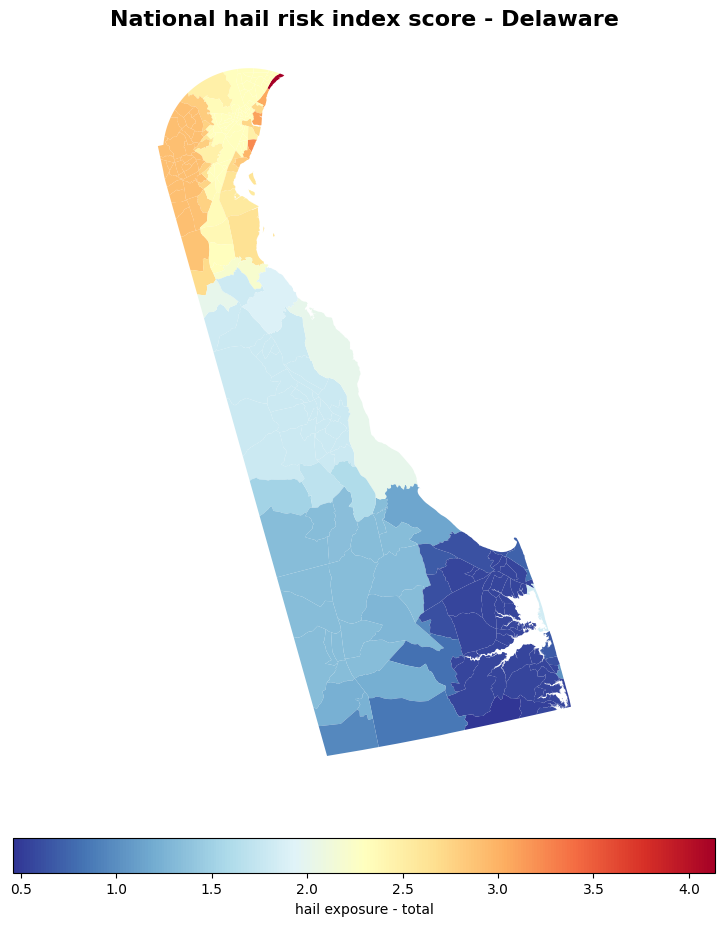

In [25]:
state_name = "Delaware"
state_map = tracts_clean[tracts_clean["STATE"].str.lower()==state_name.lower()]
fig, ax = plt.subplots(1,1,figsize=(12,10))
state_map.plot(
    column="HAIL_AFREQ",
    cmap="RdYlBu_r",
    aspect = 1,
    linewidth=0.0,
    ax=ax,
    legend=True,
    legend_kwds={'label':'hail exposure - total','orientation':'horizontal','shrink':0.6,'pad':0.05},
    missing_kwds={'color':'lightgrey','label':'no data'})
ax.set_title(f"National hail risk index score - {state_name}",fontsize=16, fontweight = "bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

C:\Users\owens\AppData\Local\Programs\Python\Python314\Lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


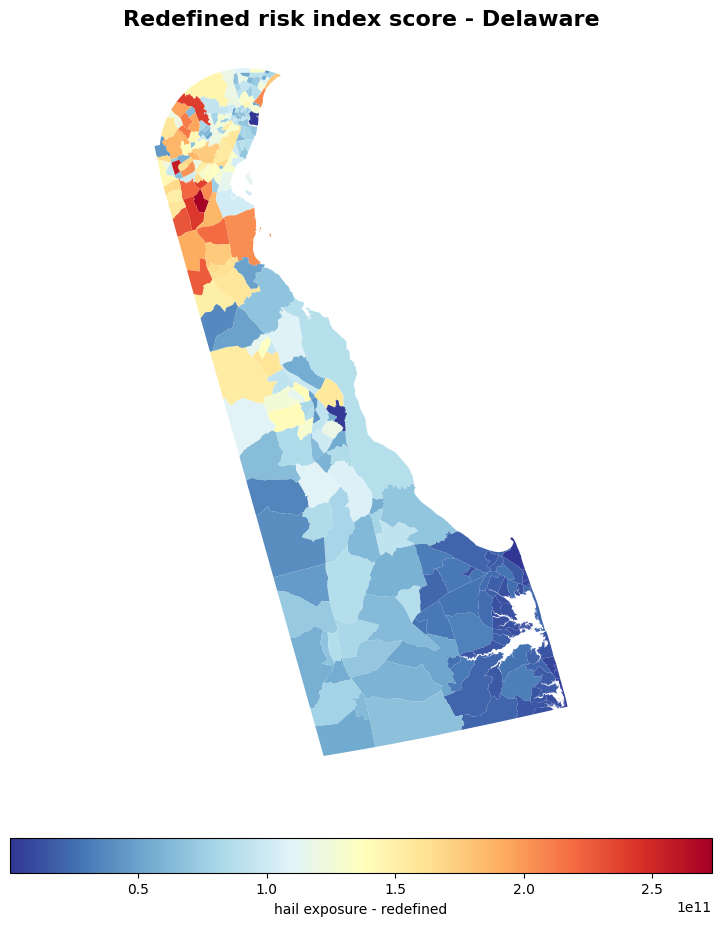

In [32]:
state_map = tracts_clean[tracts_clean["STATE"].str.lower()==state_name.lower()]
state_map['hail_risk']=state_map['HAIL_AFREQ']*state_map['HAIL_EXPT']
fig, ax = plt.subplots(1,1,figsize=(12,10))
state_map.plot(
    column="hail_risk",
    cmap="RdYlBu_r",
    aspect = 1,
    linewidth=0.0,
    ax=ax,
    legend=True,
    legend_kwds={'label':'hail exposure - redefined','orientation':'horizontal','shrink':0.6,'pad':0.05},
    missing_kwds={'color':'lightgrey','label':'no data'})
ax.set_title(f"Redefined risk index score - {state_name}",fontsize=16, fontweight = "bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

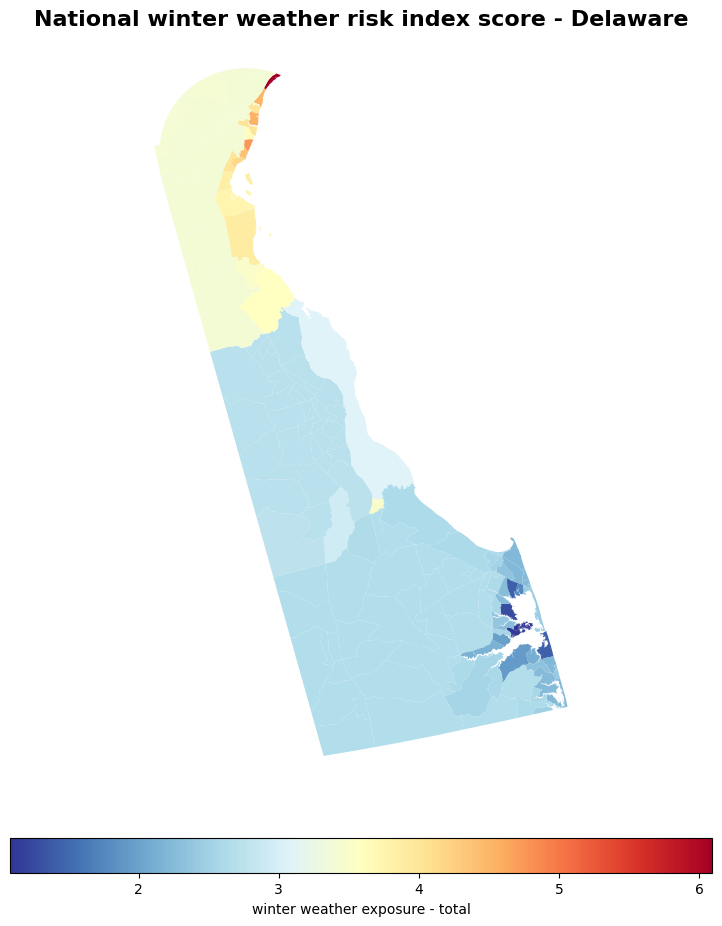

In [28]:
state_map = tracts_clean[tracts_clean["STATE"].str.lower()==state_name.lower()]
fig, ax = plt.subplots(1,1,figsize=(12,10))
state_map.plot(
    column="WNTW_AFREQ",
    cmap="RdYlBu_r",
    aspect = 1,
    linewidth=0.0,
    ax=ax,
    legend=True,
    legend_kwds={'label':'winter weather exposure - total','orientation':'horizontal','shrink':0.6,'pad':0.05},
    missing_kwds={'color':'lightgrey','label':'no data'})
ax.set_title(f"National winter weather risk index score - {state_name}",fontsize=16, fontweight = "bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

C:\Users\owens\AppData\Local\Programs\Python\Python314\Lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


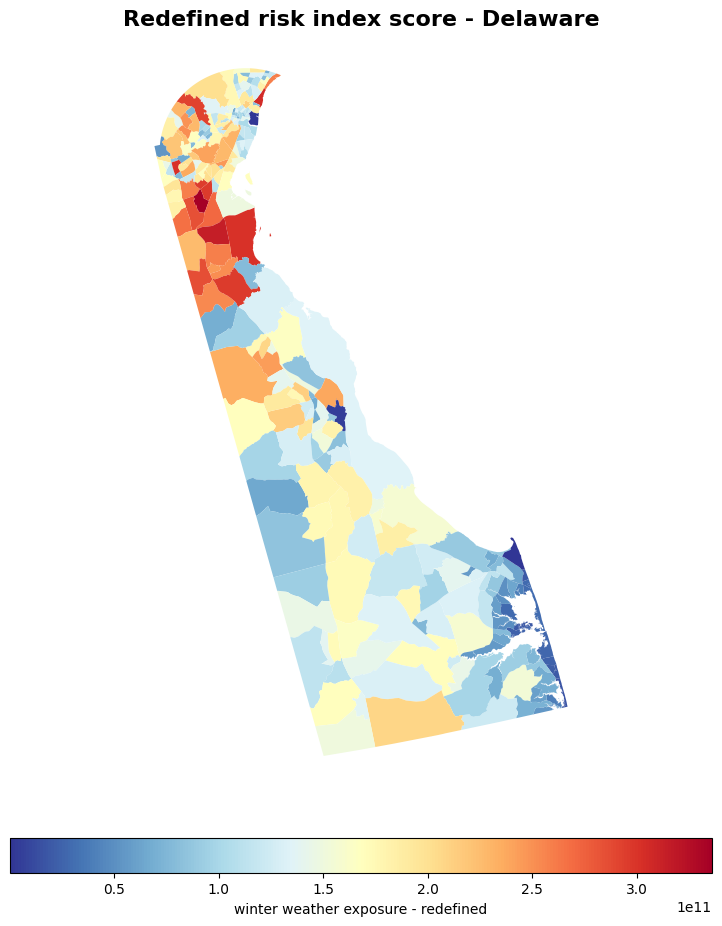

In [31]:
state_map = tracts_clean[tracts_clean["STATE"].str.lower()==state_name.lower()]
state_map['winter_risk']=state_map['WNTW_AFREQ']*state_map['WNTW_EXPT']
fig, ax = plt.subplots(1,1,figsize=(12,10))
state_map.plot(
    column="winter_risk",
    cmap="RdYlBu_r",
    aspect = 1,
    linewidth=0.0,
    ax=ax,
    legend=True,
    legend_kwds={'label':'winter weather exposure - redefined','orientation':'horizontal','shrink':0.6,'pad':0.05},
    missing_kwds={'color':'lightgrey','label':'no data'})
ax.set_title(f"Redefined risk index score - {state_name}",fontsize=16, fontweight = "bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()